In [ ]:
#Dzisiaj spróbuje zrobić wizualizacje danych, zrobię Similarity Heatmape (kolorowa mapa podobieństw molekul)
#Przytocze biblioteki takie jak matplotlib i seaborn
#Zrobie wykresy rożnych descriptorów, Grouping chemiczny
#Wczytam prawdziwy csv :DDDD

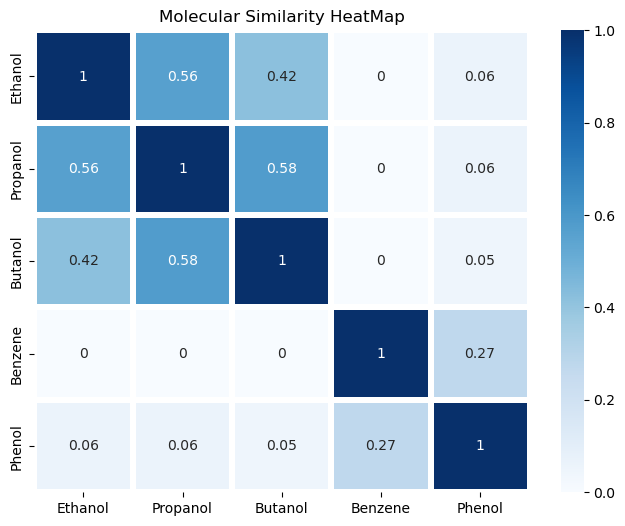

In [35]:
from rdkit import Chem #z rdkit pobieram Chem
from rdkit.Chem import rdFingerprintGenerator #Narzedzie do generowania fingerprintow
from rdkit.DataStructs import TanimotoSimilarity #Sprawdzanie Podobieństwa fingerprintow

import pandas as pd #Tabele

import seaborn as sns #Robi estetyczne wykresy
import matplotlib.pyplot as plt #Podstawowa biblioteka wykresów

molecules = [ #Każdy element z zbioru molecules ma ("nazwe", "smiles")
    ("Ethanol", "CCO"),

    ("Propanol", "CCCO"),

    ("Butanol", "CCCCO"),

    ("Benzene", "c1ccccc1"),

    ("Phenol", "c1ccccc1O")
]
morgan_gen = rdFingerprintGenerator.GetMorganGenerator( #Tworze generator Fingerprintów Morgana
    radius=2, #Rdkit patrzy na dwa kroki 
    fpSize=1024 #Fingerprint bedzie mial 1024 bitów
)
fps=[] #Lista na fingerprinty
names=[] #Lista na nazwy związków

for name, smiles in molecules: #Pętla bierze nazwe i smiles dla kazdej molekuły w zbiorze "molecules"
    mol =Chem.MolFromSmiles(smiles) #Smiles na obiekt molekuł z zbioru "molecules"
    fp =morgan_gen.GetFingerprint(mol) #Z obiektów wytworzonych linijke wyżej generuje fingerprinty morgana
    fps.append(fp) #Dołączam zmienna fp (czyli fingerprinty) do pustej listy "fps" (MUSI BYC W PETLI CALY CZAS)
    names.append(name) #Nazwe każdej molekuły dodaje do pustej listy "names"

similarity_matrix = [] #Pusta lista dla podobieństw
for fp1 in fps: #Bierze jeden fingerprint (Outer Loop)
    row=[] #tworzy liste row
    for fp2 in fps: # Porównuje go ze wszystkimi fingerprintami(Inner Loop)
        similarity =TanimotoSimilarity(fp1, #Liczy podobieństwo fingerprintów
                                       fp2
                                      )
        row.append(round(similarity,2)) #Dodaje wynik similarity do jednego wiersza.


    similarity_matrix.append(row) #Dodaje cały wiersz do całej macierzy.

df_similarity =pd.DataFrame( #Pandas tworzy tabele similarity
    similarity_matrix,
    index=names, #Nazwa wierszy
    columns=names #Nazwa kolumn
)

plt.figure(figsize=(8,6)) #Tworzy figure wykresu i podaje rozmiar wykresu 
sns.heatmap( #tworze heatmape
    df_similarity, #Tutaj wstawiam dane wejściowe do naszej heatmapy
    annot=True, #Pokazuje liczby
    cmap="Blues",#Tutaj wybieram kolory
    linewidths=3
)
plt.title("Molecular Similarity HeatMap") #Dodawanie tytułu
plt.show() #Wyświetlanie wykresu

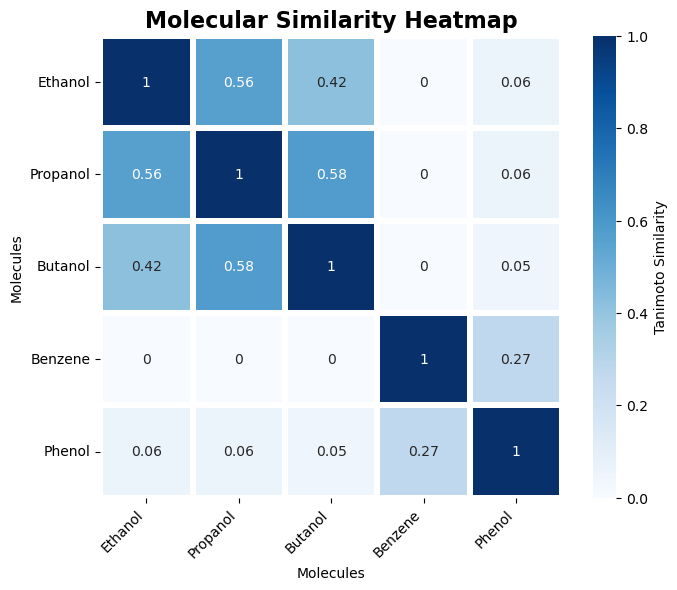

In [50]:
from rdkit import Chem #z rdkit pobieram Chem
from rdkit.Chem import rdFingerprintGenerator #Narzedzie do generowania fingerprintow
from rdkit.DataStructs import TanimotoSimilarity #Sprawdzanie Podobieństwa fingerprintow

import pandas as pd #Tabele

import seaborn as sns #Robi estetyczne wykresy
import matplotlib.pyplot as plt #Podstawowa biblioteka wykresów

molecules = [ #Każdy element z zbioru molecules ma ("nazwe", "smiles")
    ("Ethanol", "CCO"),

    ("Propanol", "CCCO"),

    ("Butanol", "CCCCO"),

    ("Benzene", "c1ccccc1"),

    ("Phenol", "c1ccccc1O")
]
morgan_gen = rdFingerprintGenerator.GetMorganGenerator( #Tworze generator Fingerprintów Morgana
    radius=2, #Rdkit patrzy na dwa kroki 
    fpSize=1024 #Fingerprint bedzie mial 1024 bitów
)
fps=[] #Lista na fingerprinty
names=[] #Lista na nazwy związków

for name, smiles in molecules: #Pętla bierze nazwe i smiles dla kazdej molekuły w zbiorze "molecules"
    mol =Chem.MolFromSmiles(smiles) #Smiles na obiekt molekuł z zbioru "molecules"
    fp =morgan_gen.GetFingerprint(mol) #Z obiektów wytworzonych linijke wyżej generuje fingerprinty morgana
    fps.append(fp) #Dołączam zmienna fp (czyli fingerprinty) do pustej listy "fps" (MUSI BYC W PETLI CALY CZAS)
    names.append(name) #Nazwe każdej molekuły dodaje do pustej listy "names"

similarity_matrix = [] #Pusta lista dla podobieństw
for fp1 in fps: #Bierze jeden fingerprint (Outer Loop)
    row=[] #tworzy liste row
    for fp2 in fps: # Porównuje go ze wszystkimi fingerprintami(Inner Loop)
        similarity =TanimotoSimilarity(fp1, #Liczy podobieństwo fingerprintów
                                       fp2
                                      )
        row.append(round(similarity,2)) #Dodaje wynik similarity do jednego wiersza.


    similarity_matrix.append(row) #Dodaje cały wiersz do całej macierzy.

df_similarity =pd.DataFrame( #Pandas tworzy tabele similarity
    similarity_matrix,
    index=names, #Nazwa wierszy
    columns=names #Nazwa kolumn
)

plt.figure(figsize=(8,6)) #Tworzy figure wykresu i podaje rozmiar wykresu 
sns.heatmap( #tworze heatmape
    df_similarity, #Tutaj wstawiam dane wejściowe do naszej heatmapy
    annot=True, #Pokazuje liczby
    cmap="Blues",#Tutaj wybieram kolory
    linewidths=3, #Linie Miedzy kwadratami
    linecolor="White", #Kolor lini
    square=True, #komórki sa kwadratowe
    vmin=0, #Wartosc Min
    vmax=1, #Wartosc Max
    cbar_kws={"label": "Tanimoto Similarity"} #Opis paska koloru Tanimoto Similarity ten po prawej
        
)
plt.title("Molecular Similarity Heatmap", fontsize=16, fontweight="bold")#Dodawanie tytułu
plt.xlabel("Molecules") # Legenda
plt.ylabel("Molecules") # Legenda

plt.xticks(rotation=45, ha="right") #obkrecanie Legendy
plt.yticks(rotation=0)

plt.tight_layout()#Poprawa układu zeby napisy nie były ucięte ale bez tego tez dziala
plt.show() #Wyświetlanie wykresu